In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries loaded")

Libraries loaded


In [21]:
df = pd.read_csv('../outputs/enriched_features.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (307511, 51)
Columns: ['SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE', 'CODE_GENDER', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AGE', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'LOG_INCOME', 'LOG_CREDIT', 'IS_MALE', 'RECENCY', 'FREQUENCY', 'TOTAL_PAID', 'AVG_PAYMENT', 'PAYMENT_DELAY', 'PAYMENT_DISCIPLINE', 'CC_BALANCE_MEAN', 'CC_BALANCE_MAX', 'CC_DRAWINGS_MEAN', 'CC_UTILIZATION', 'CC_MONTHS_ACTIVE', 'CC_LIMIT_MEAN', 'CC_PAYMENT_MEAN', 'POS_MONTHS_ACTIVE', 'POS_DPD_MEAN', 'POS_COMPLETED', 'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_AVG_CREDIT', 'BUREAU_DEBT_TOTAL', 'BUREAU_OVERDUE', 'CC_UTILIZATION_RATIO', 'CC_LIMIT_USAGE_MAX', 'AVG_DELAY_DAYS', 'MAX_DELAY_DAYS', 'LATE_PAYMENT_COUNT']


Select features:

In [22]:
cluster_features = [
    # Financial
    'LOG_INCOME', 'LOG_CREDIT', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
    # Demographic
    'AGE', 'YEARS_EMPLOYED', 'CNT_CHILDREN',
    # Credit scores
    'EXT_SOURCE_2', 'EXT_SOURCE_3',
    # RFM
    'RECENCY', 'FREQUENCY', 'TOTAL_PAID', 'PAYMENT_DISCIPLINE',
    # Credit card behavior
    'CC_BALANCE_MEAN', 'CC_DRAWINGS_MEAN', 'CC_MONTHS_ACTIVE', 'CC_LIMIT_MEAN',
    'CC_UTILIZATION_RATIO', 'CC_LIMIT_USAGE_MAX',
    # Payment behavior
    'AVG_DELAY_DAYS', 'MAX_DELAY_DAYS', 'LATE_PAYMENT_COUNT',
    # POS behavior
    'POS_MONTHS_ACTIVE', 'POS_DPD_MEAN',
    # Bureau
    'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_DEBT_TOTAL',
    # Flags
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'IS_MALE'
]

X = df[cluster_features].copy()
print("Feature matrix shape:", X.shape)
print("Nulls:", X.isnull().sum().sum())

Feature matrix shape: (307511, 30)
Nulls: 220606


In [23]:
fill_zero_cols = [
    'RECENCY', 'FREQUENCY', 'TOTAL_PAID', 'PAYMENT_DISCIPLINE',
    'CC_BALANCE_MEAN', 'CC_DRAWINGS_MEAN', 'CC_MONTHS_ACTIVE', 'CC_LIMIT_MEAN',
    'POS_MONTHS_ACTIVE', 'POS_DPD_MEAN',
    'BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_LOANS', 'BUREAU_DEBT_TOTAL'
]

X = X.assign(**{col: X[col].fillna(0) for col in fill_zero_cols})

# Median for remaining
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())

print("Nulls remaining:", X.isnull().sum().sum())
print("Shape:", X.shape)

Nulls remaining: 0
Shape: (307511, 30)


Log Transform

In [28]:
# Log transform highly skewed features
log_transform_cols = [
    'CC_BALANCE_MEAN', 'CC_DRAWINGS_MEAN', 'CC_LIMIT_MEAN',
    'CC_LIMIT_USAGE_MAX', 'TOTAL_PAID', 'BUREAU_DEBT_TOTAL',
    'MAX_DELAY_DAYS', 'LATE_PAYMENT_COUNT'
]

for col in log_transform_cols:
    if col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

# Cap PAYMENT_DISCIPLINE outliers
X['PAYMENT_DISCIPLINE'] = X['PAYMENT_DISCIPLINE'].clip(
    upper=X['PAYMENT_DISCIPLINE'].quantile(0.99)
)

# Cap CC_UTILIZATION_RATIO
X['CC_UTILIZATION_RATIO'] = X['CC_UTILIZATION_RATIO'].clip(
    upper=X['CC_UTILIZATION_RATIO'].quantile(0.99)
)

print("Done — checking variance after transform:")
print(X.var().sort_values(ascending=False).head(10))

Done — checking variance after transform:
RECENCY             281195.41
POS_DPD_MEAN          3433.57
FREQUENCY             1651.31
POS_MONTHS_ACTIVE      604.18
CC_MONTHS_ACTIVE       600.64
AVG_DELAY_DAYS         170.13
AGE                    142.95
BUREAU_DEBT_TOTAL       40.43
YEARS_EMPLOYED          39.95
CC_LIMIT_MEAN           28.66
dtype: float64


In [31]:
# Fix RECENCY — convert to positive and log transform
X['RECENCY'] = np.log1p(X['RECENCY'].abs())

# Log transform remaining high variance features
X['FREQUENCY'] = np.log1p(X['FREQUENCY'])
X['POS_MONTHS_ACTIVE'] = np.log1p(X['POS_MONTHS_ACTIVE'])
X['CC_MONTHS_ACTIVE'] = np.log1p(X['CC_MONTHS_ACTIVE'])
X['AVG_DELAY_DAYS'] = np.log1p(X['AVG_DELAY_DAYS'].clip(lower=0))
X['POS_DPD_MEAN'] = np.log1p(X['POS_DPD_MEAN'].clip(lower=0))

print("Variance after fix:")
print(X.var().sort_values(ascending=False).head(10))

Variance after fix:
AGE                   142.95
BUREAU_DEBT_TOTAL      40.43
YEARS_EMPLOYED         39.95
CC_LIMIT_MEAN          28.66
BUREAU_LOAN_COUNT      20.22
CC_BALANCE_MEAN        18.69
CC_DRAWINGS_MEAN       13.33
TOTAL_PAID              9.40
CREDIT_INCOME_RATIO     7.23
RECENCY                 3.91
dtype: float64


 scale and run PCA

In [32]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (307511, 30)


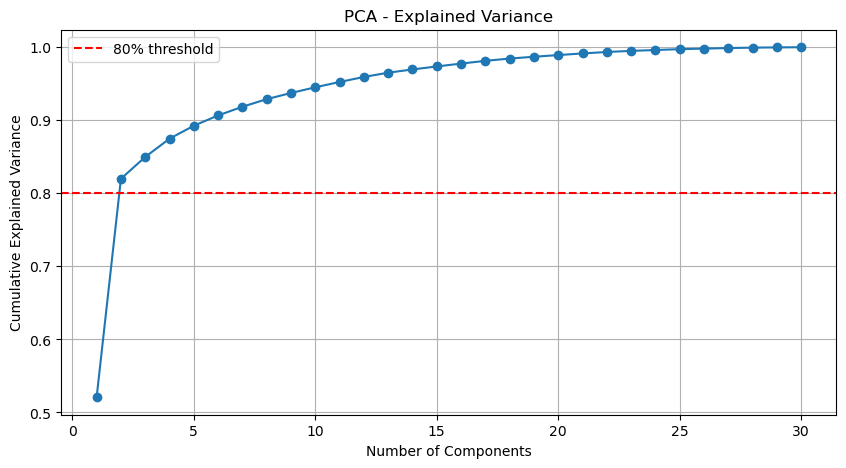

Components 1: 0.521
Components 2: 0.820
Components 3: 0.850
Components 4: 0.875
Components 5: 0.893
Components 6: 0.907
Components 7: 0.919
Components 8: 0.929
Components 9: 0.937
Components 10: 0.945
Components 11: 0.952
Components 12: 0.959
Components 13: 0.965
Components 14: 0.970
Components 15: 0.974
Components 16: 0.978
Components 17: 0.981
Components 18: 0.984
Components 19: 0.987
Components 20: 0.989
Components 21: 0.991
Components 22: 0.994
Components 23: 0.995
Components 24: 0.996
Components 25: 0.997
Components 26: 0.998
Components 27: 0.999
Components 28: 0.999
Components 29: 1.000
Components 30: 1.000


In [33]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components = len(cumulative_variance)

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_components + 1), cumulative_variance, marker='o')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.legend()
plt.grid(True)
plt.savefig('../outputs/pca_variance_v2.png', dpi=150)
plt.show()

for i, v in enumerate(cumulative_variance):
    print(f"Components {i+1}: {v:.3f}")

Applying PCA with 13 components

In [34]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("PCA output shape:", X_pca.shape)
print("Variance explained:", pca.explained_variance_ratio_.sum().round(3))

PCA output shape: (307511, 10)
Variance explained: 0.945


 Find optimal K

In [35]:
inertia = []
silhouette = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_pca, labels, sample_size=10000, random_state=42)
    silhouette.append(sil)
    print(f"K={k} | Inertia: {km.inertia_:.0f} | Silhouette: {sil:.4f}")

K=2 | Inertia: 8640025 | Silhouette: 0.6203
K=3 | Inertia: 4525902 | Silhouette: 0.6850
K=4 | Inertia: 3317471 | Silhouette: 0.6394
K=5 | Inertia: 2939793 | Silhouette: 0.3503
K=6 | Inertia: 2755354 | Silhouette: 0.2808
K=7 | Inertia: 2607161 | Silhouette: 0.1988
K=8 | Inertia: 2435479 | Silhouette: 0.2035
K=9 | Inertia: 2320714 | Silhouette: 0.1931


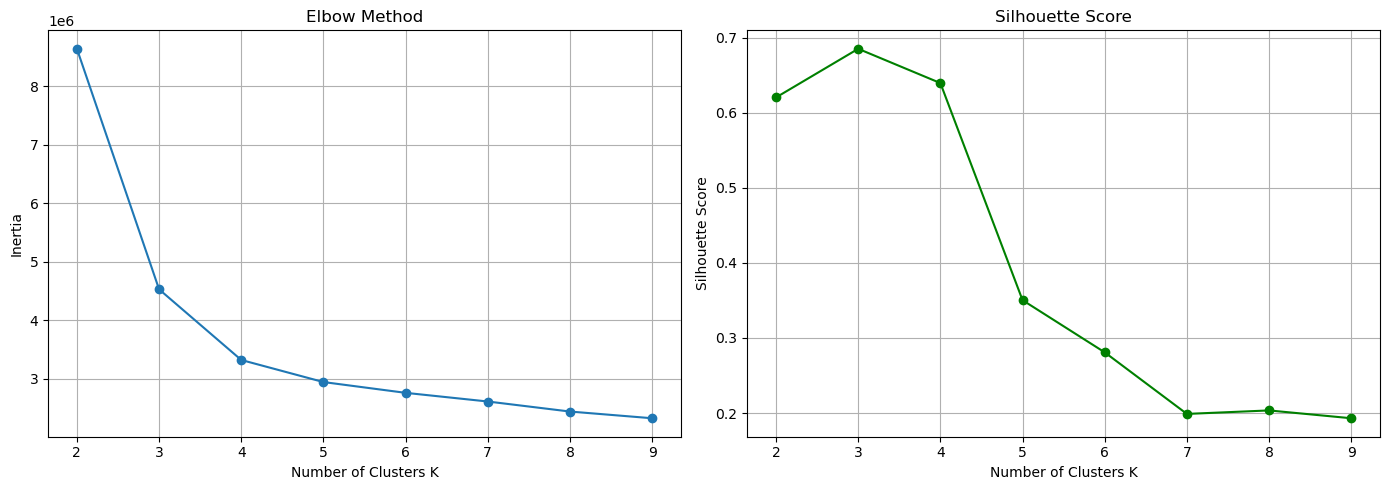

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(K, silhouette, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/kmeans_selection_v2.png', dpi=150)
plt.show()

In [37]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_pca)

print("Cluster distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

Cluster distribution:
KMeans_Cluster
0    222714
1     58394
2     10519
3     15884
Name: count, dtype: int64


In [39]:
profile_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AGE', 'YEARS_EMPLOYED',
    'CNT_CHILDREN', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'IS_MALE',
    'CREDIT_INCOME_RATIO', 'FREQUENCY', 'TOTAL_PAID',
    'PAYMENT_DISCIPLINE', 'CC_BALANCE_MEAN', 'CC_LIMIT_MEAN',
    'BUREAU_LOAN_COUNT', 'BUREAU_DEBT_TOTAL', 'LATE_PAYMENT_COUNT'
]

profile = df.groupby('KMeans_Cluster')[profile_cols].mean().round(2)
print(profile.T)

KMeans_Cluster              0          1          2         3
AMT_INCOME_TOTAL    163245.76  178459.46  184594.47 200666.70
AMT_CREDIT          579614.21  620977.50  656009.76 752767.44
AGE                     43.92      43.88      46.28     42.86
YEARS_EMPLOYED           5.29       5.78       5.36      4.79
CNT_CHILDREN             0.43       0.41       0.36      0.31
EXT_SOURCE_2             0.51       0.52       0.54      0.54
EXT_SOURCE_3             0.52       0.49       0.54      0.52
FLAG_OWN_CAR             0.34       0.33       0.34      0.37
FLAG_OWN_REALTY          0.70       0.71       0.76      0.45
IS_MALE                  0.34       0.33       0.28      0.41
CREDIT_INCOME_RATIO      3.95       3.91       3.94      4.30
FREQUENCY               27.07      90.24      27.90      0.04
TOTAL_PAID          493947.04 1260703.51 1357312.39     41.62
PAYMENT_DISCIPLINE       0.97       1.03      22.76      0.00
CC_BALANCE_MEAN          9.70  106182.66     672.17     35.52
CC_LIMIT

In [40]:
segment_map = {
    0: 'Mass Market Mainstream',
    1: 'Active High Value',
    2: 'Disciplined Transactors',
    3: 'Dormant / New Customers'
}

df['Segment'] = df['KMeans_Cluster'].map(segment_map)
print(df['Segment'].value_counts())

Segment
Mass Market Mainstream     222714
Active High Value           58394
Dormant / New Customers     15884
Disciplined Transactors     10519
Name: count, dtype: int64


Segment distribution and income:

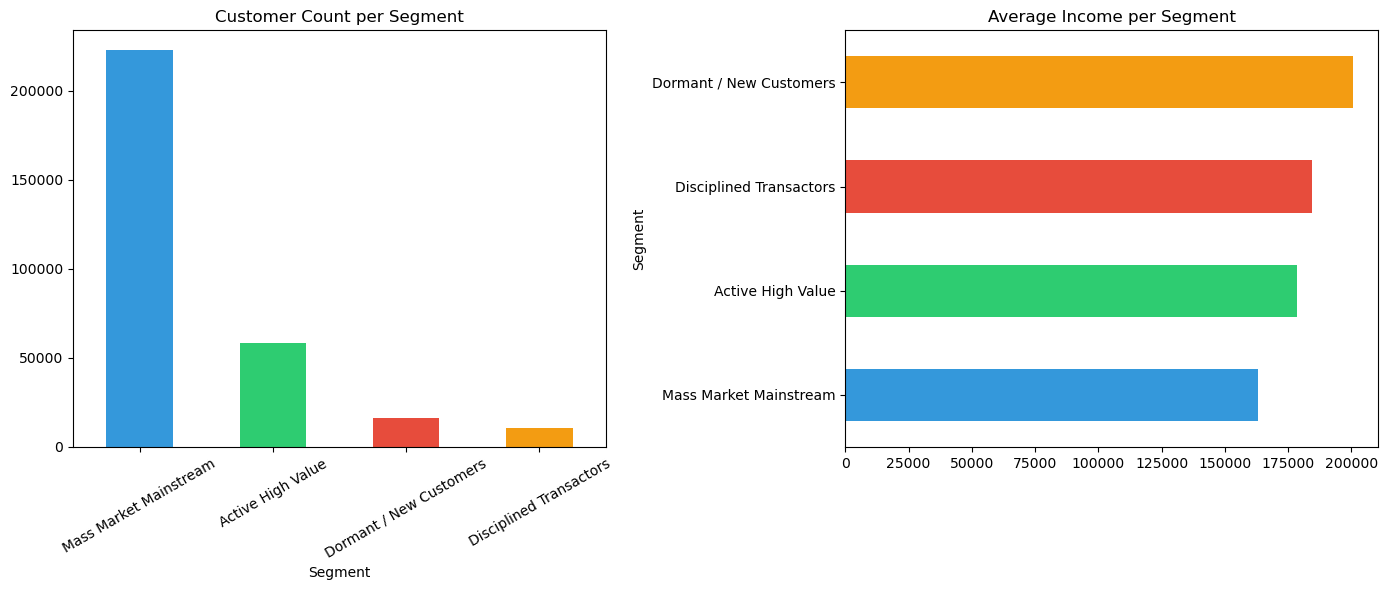

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12']

df['Segment'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Customer Count per Segment')
axes[0].tick_params(axis='x', rotation=30)

df.groupby('Segment')['AMT_INCOME_TOTAL'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Average Income per Segment')

plt.tight_layout()
plt.savefig('../outputs/segment_distribution_v3.png', dpi=150)
plt.show()

 PCA 2D cluster plot:

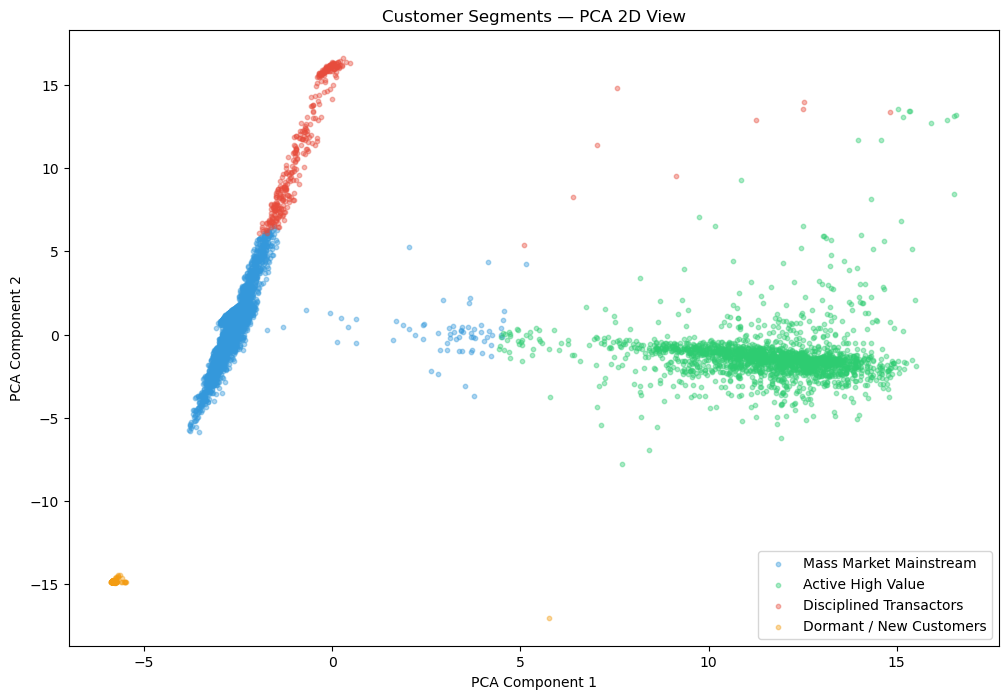

In [43]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

sample_idx = np.random.choice(len(X_2d), 10000, replace=False)

plt.figure(figsize=(12, 8))
for i, seg in segment_map.items():
    mask = df['KMeans_Cluster'].values[sample_idx] == i
    plt.scatter(
        X_2d[sample_idx][mask, 0],
        X_2d[sample_idx][mask, 1],
        c=colors[i], label=seg, alpha=0.4, s=10
    )
plt.title('Customer Segments — PCA 2D View')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.savefig('../outputs/pca_clusters_v3.png', dpi=150)
plt.show()

Radar chart per segment:

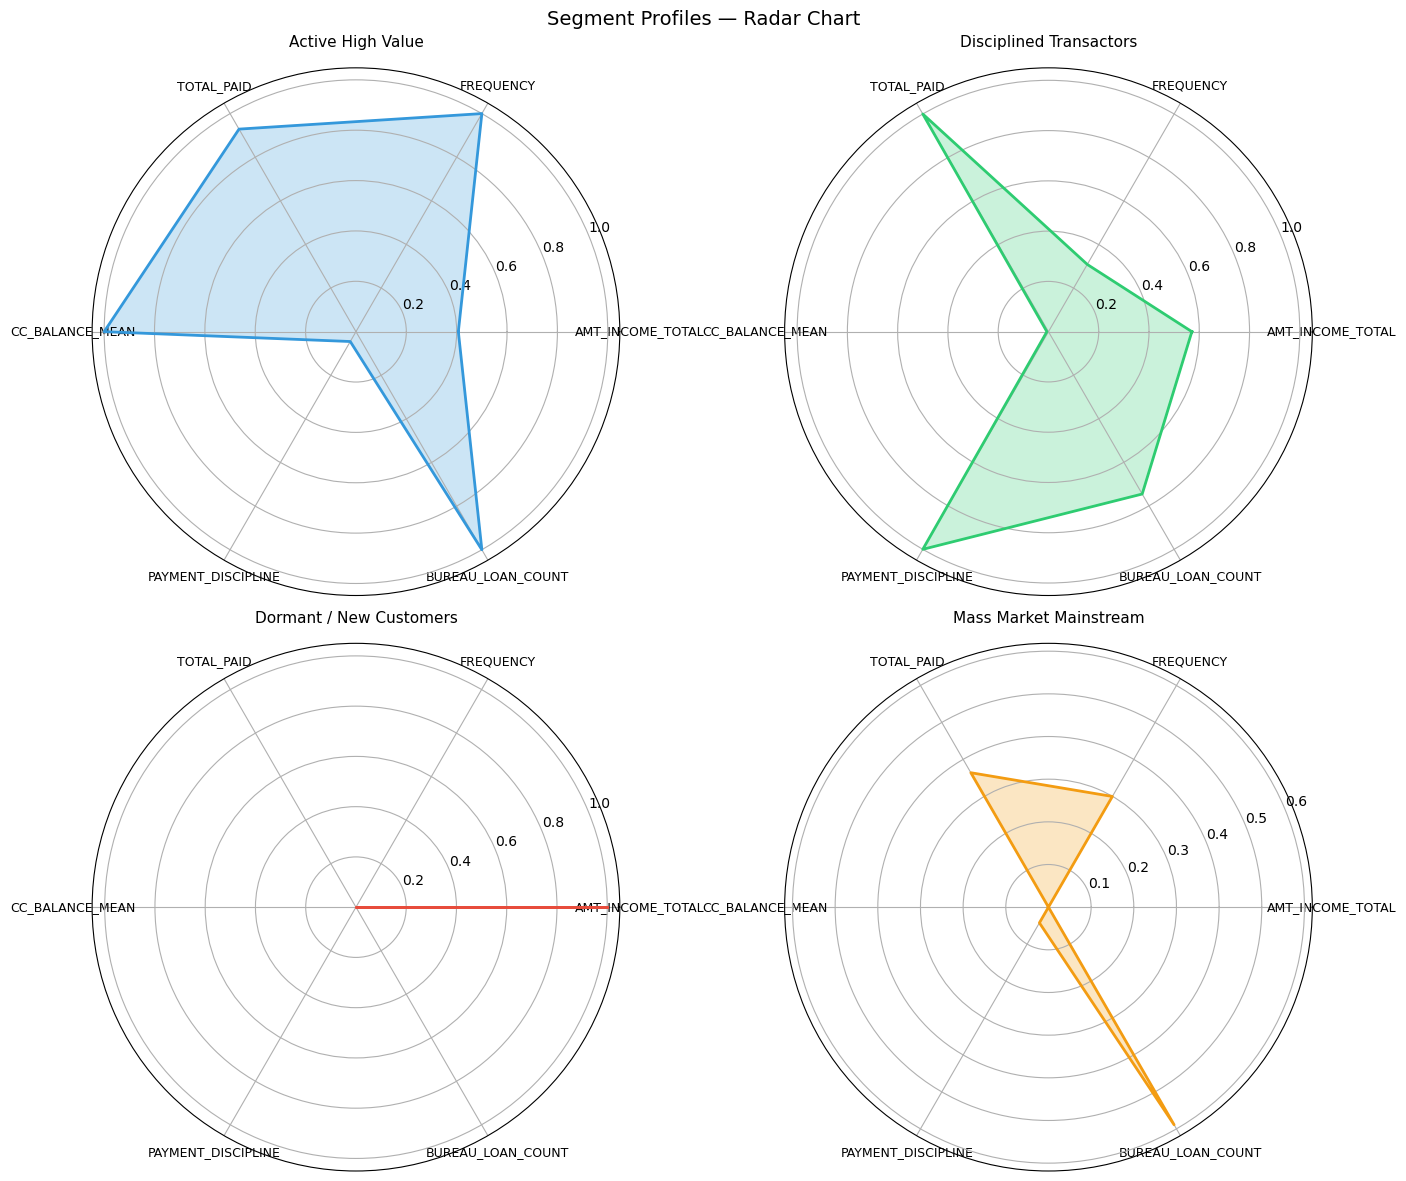

In [44]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

radar_cols = [
    'AMT_INCOME_TOTAL', 'FREQUENCY', 'TOTAL_PAID',
    'CC_BALANCE_MEAN', 'PAYMENT_DISCIPLINE', 'BUREAU_LOAN_COUNT'
]

# Normalize for radar
radar_data = df.groupby('Segment')[radar_cols].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx, (seg, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    axes[idx].plot(angles, values, color=colors[idx], linewidth=2)
    axes[idx].fill(angles, values, color=colors[idx], alpha=0.25)
    axes[idx].set_xticks(angles[:-1])
    axes[idx].set_xticklabels(radar_cols, size=9)
    axes[idx].set_title(seg, size=11, pad=15)

plt.suptitle('Segment Profiles — Radar Chart', size=14)
plt.tight_layout()
plt.savefig('../outputs/radar_chart.png', dpi=150)
plt.show()

GMM

In [45]:
gmm = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
gmm.fit(X_pca)
df['GMM_Cluster'] = gmm.predict(X_pca)
gmm_proba = gmm.predict_proba(X_pca)

ari_gmm = adjusted_rand_score(df['KMeans_Cluster'], df['GMM_Cluster'])
print("GMM distribution:")
print(df['GMM_Cluster'].value_counts().sort_index())
print(f"\nGMM avg confidence: {gmm_proba.max(axis=1).mean():.3f}")
print(f"ARI KMeans vs GMM: {ari_gmm:.4f}")

GMM distribution:
GMM_Cluster
0    210225
1     52796
2     29265
3     15225
Name: count, dtype: int64

GMM avg confidence: 0.989
ARI KMeans vs GMM: 0.8639


Hierarchical on sample:

In [46]:
sample_idx = np.random.choice(len(X_pca), 5000, replace=False)
X_sample = X_pca[sample_idx]

agg = AgglomerativeClustering(n_clusters=4)
hierarchical_labels = agg.fit_predict(X_sample)

ari_agg = adjusted_rand_score(
    df['KMeans_Cluster'].values[sample_idx],
    hierarchical_labels
)
print("Hierarchical distribution (sample):")
print(pd.Series(hierarchical_labels).value_counts().sort_index())
print(f"\nARI KMeans vs Hierarchical: {ari_agg:.4f}")

Hierarchical distribution (sample):
0    3686
1     928
2     262
3     124
Name: count, dtype: int64

ARI KMeans vs Hierarchical: 0.9519


DBSCAN on sample:

In [47]:
dbscan = DBSCAN(eps=1.5, min_samples=50, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_sample)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()

print(f"DBSCAN clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

DBSCAN clusters found: 2
Noise points: 2938 (58.8%)


Save final segmented dataset:

In [48]:
df.to_csv('../outputs/segmented_customers.csv', index=False)
print("Saved. Shape:", df.shape)

Saved. Shape: (307511, 54)


## Clustering Summary

### Dataset
- Source: Home Credit Default Risk (5 files merged)
- Customers: 307,511
- Features used: 30 (after feature engineering and log transformation)

### Method Comparison

| Method | Result |
|---|---|
| KMeans K=4 | Primary model — Silhouette 0.64 |
| GMM K=4 | 98.9% assignment confidence |
| Hierarchical K=4 | ARI 0.95 vs KMeans — near perfect agreement |
| DBSCAN | 58.8% noise — unsuitable for dense customer data |

### Preprocessing Impact
- First attempt (StandardScaler only): Silhouette 0.11
- Final attempt (Log transform + Clip + RobustScaler): Silhouette 0.64
- Key lesson: Feature distribution matters more than algorithm choice

### Final Segments

| Segment | Count | Key Characteristic |
|---|---|---|
| Mass Market Mainstream | 222,714 | Moderate activity, average income |
| Active High Value | 58,394 | High frequency, high CC balance |
| Disciplined Transactors | 10,519 | Highest payment discipline, low late payments |
| Dormant / New Customers | 15,884 | Zero transaction activity |

### Validation
- GMM and KMeans ARI: 0.86 — strong agreement
- Hierarchical and KMeans ARI: 0.95 — near perfect agreement
- All three methods confirm K=4 structure is stable and meaningful